In [1]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [18]:
block_size = 3

def build_dataset(words):
	X, Y = [], []
	for w in words:
		context = [0] * block_size
		for ch in w + '.':
			ix = stoi[ch]
			X.append(context)
			Y.append(ix)
			context = context[1:] + [ix]
	X = torch.tensor(X)
	Y = torch.tensor(Y)
	print(X.shape, Y.shape)
	return X, Y

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_embd = 10
n_hidden = 200

g  = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3) / ((block_size * n_embd)**0.5)
# b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
	p.requires_grad = True

12297


In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
	ix = torch.randint(0 ,Xtr.shape[0], (batch_size, ), generator=g)
	Xb, Yb = Xtr[ix], Ytr[ix]
	#forward pass

	emb = C[Xb]
	embcat = emb.view(emb.shape[0], -1)
	hpreact = embcat @ W1
	bnmeani = hpreact.mean(0, keepdim=True)
	bnstdi = hpreact.std(0, keepdim=True)
	hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

	with torch.no_grad():
		bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
		bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
	h = torch.tanh(hpreact)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Yb)

	#backward pass
	for p in parameters:
		p.grad = None
	loss.backward()

	#update
	lr = 0.1 if i < 100000 else 0.01
	for p in parameters:
		p.data -= lr * p.grad

	lossi.append(loss.log10().item())
	if i % 10000 == 0:
		print(f"{i:7d}/{max_steps:7d} : {loss.item():.4f}")


      0/ 200000 : 3.3147
  10000/ 200000 : 2.1984
  20000/ 200000 : 2.3375
  30000/ 200000 : 2.4359
  40000/ 200000 : 2.0119
  50000/ 200000 : 2.2595
  60000/ 200000 : 2.4775
  70000/ 200000 : 2.1020
  80000/ 200000 : 2.2788
  90000/ 200000 : 2.1862
 100000/ 200000 : 1.9474
 110000/ 200000 : 2.3010
 120000/ 200000 : 1.9837
 130000/ 200000 : 2.4523
 140000/ 200000 : 2.3839
 150000/ 200000 : 2.1987
 160000/ 200000 : 1.9733
 170000/ 200000 : 1.8668
 180000/ 200000 : 1.9973
 190000/ 200000 : 1.8347


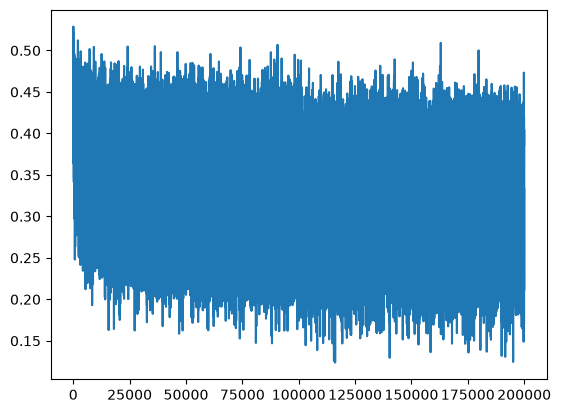

In [47]:
plt.plot(lossi)

In [48]:
with torch.no_grad():
	emb = C[Xtr]
	embcat = emb.view(emb.shape[0], -1)
	hpreact = embcat @ W1 + b1
	bnmean = hpreact.mean(0, keepdim=True)
	bnstd = hpreact.std(0, keepdim=True)

In [49]:
bnmean

tensor([[-2.3355,  0.6776, -0.9133,  1.0163,  1.0865,  1.0938,  1.7437, -2.1208,
          0.5730,  1.4455, -1.6343, -2.7372, -0.4752, -0.1412, -0.0745, -1.1722,
          0.6851, -2.6219, -0.1065,  1.6326, -0.7706, -0.3063,  0.0479,  0.6115,
          1.1173,  0.2427,  2.0500,  0.5831,  0.8527,  1.7680, -0.3625, -0.8355,
         -0.0854, -0.5177, -0.3806, -1.0699, -0.0786,  0.3487, -0.5808,  0.9875,
         -0.4427, -1.3082, -0.2871, -0.2332,  0.6850,  0.6850,  2.0857, -0.7608,
          2.3866,  1.8734,  0.8259,  0.2803,  1.8897,  0.4709,  0.6739, -1.8940,
         -0.0401,  0.4338,  1.3760, -0.8910, -0.4524,  1.1754,  0.5613,  0.6051,
          1.5859,  1.2261, -1.0111,  2.1495, -0.6392,  0.0938, -0.2864, -0.4856,
          0.9632, -1.0461, -2.9990,  0.6391,  1.4327, -0.1590,  0.0941,  0.5253,
          0.2508,  1.2521,  2.0388,  0.6608,  0.0691, -0.0813, -1.6724,  0.2933,
          2.2423, -0.0210, -0.6666,  1.4253, -0.8412, -1.2248, -1.0129,  0.2230,
          0.2112, -0.3226,  

In [50]:
bnmean_running

tensor([[-2.3539,  0.6872, -0.9000,  1.0159,  1.0894,  1.0862,  1.7389, -2.1356,
          0.5608,  1.4246, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
          0.6891, -2.6399, -0.1283,  1.6240, -0.7732, -0.2864,  0.0467,  0.6119,
          1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
         -0.0831, -0.5198, -0.3817, -1.0699, -0.0781,  0.3370, -0.5769,  0.9935,
         -0.4507, -1.3313, -0.2895, -0.2298,  0.6877,  0.6936,  2.0835, -0.7759,
          2.3804,  1.8614,  0.8118,  0.2735,  1.8802,  0.4705,  0.6656, -1.8962,
         -0.0420,  0.4356,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6001,
          1.5853,  1.2103, -1.0171,  2.1422, -0.6330,  0.1071, -0.2926, -0.4831,
          0.9506, -1.0144, -2.9925,  0.6269,  1.4404, -0.1574,  0.0955,  0.5159,
          0.2487,  1.2401,  2.0104,  0.6695,  0.0768, -0.0851, -1.6768,  0.2963,
          2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
          0.1928, -0.3261,  

In [ ]:
@torch.no_grad()
def split_loss(split):
	x, y = {
		'train': (Xtr, Ytr),
		'val': (Xdev, Ydev),
		'test' : (Xte, Yte)
	}[split]
	emb = C[x]
	embcat = emb.view(emb.shape[0], -1)
	hpreact = embcat @ W1 
	# hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
	hpreact = bngain * (hpreact - bnmean_running) / bnstd + bnbias
	h = torch.tanh(hpreact)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, y)
	print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0667998790740967
val 2.1049349308013916


In [35]:
g_s = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
	out = []
	context = [0] * block_size
	while True:
		with torch.no_grad():
			emb = C[torch.tensor([context])]
			h = torch.tanh(emb.view(1, -1) @ W1 + b1)
			probs = F.softmax(h @ W2 + b2, dim=1)
		ix = torch.multinomial(probs, num_samples=1, generator=g_s).item()
		context = context[1:] + [ix]
		if ix == 0:
			break
		out.append(itos[ix])
	print(''.join(out))

carpahzarbriq
shlimrixtts
lusslaysierricnenddhn
frtivgqliyah
farrichaiirdnsleggyu
bmanvitte
sants
lustvi
vabbuwatth
giidryxiidh
sulipsables
falia
gtas
jasfaylahas
bduricsydustquovozswy
bjumillassannyks
sadlusoffordst
sramsryndlycpllmanraq
shelseombriyabhda
ffxrdustvebndvi
